# Обучение RSSM world-model (MultiObjEnv)

Собирает данные случайной политикой, обучает модель мира и сохраняет `model.pt`

In [1]:
!pip install -q -U minigrid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 3.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 91.1 MB/s eta 0:00:00:00:01:01


### 1. Импорты

In [2]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- Kaggle: датасет с файлами проекта (NN.py, RSSM.py, env_tasks.py, data.py) ---
import sys; 
sys.path.append("/kaggle/input/datasets/kirillwerd/world-model-new")

from data import collect_episodes, ReplayBuffer, ACTION_DIM
from RSSM import RSSM

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

torch 2.10.0+cu128 | device: cuda
GPU: Tesla T4


### 2. Конфиг

`QUICK=True` — быстрый прогон для проверки
`CKPT_EVERY` — как часто писать чекпоинт.

In [14]:
QUICK = False
GRID_SIZE = 10

if QUICK:
    NUM_EPISODES, MAX_LEN, STEPS = 50, 40, 300
else:
    NUM_EPISODES, MAX_LEN, STEPS = 500, 64, 1500

BATCH, CHUNK, LR = 16, 20, 1e-3
CKPT_EVERY = 300                 # чекпоинт каждые N шагов
CKPT_DIR = "/kaggle/working"     # на Kaggle -> Output; локально поставь "."

assert MAX_LEN >= CHUNK, "MAX_LEN должен быть не меньше CHUNK"
print(f"episodes={NUM_EPISODES}  steps={STEPS}  batch={BATCH}  chunk(T)={CHUNK}  ckpt/{CKPT_EVERY}")

episodes=500  steps=1500  batch=16  chunk(T)=20  ckpt/300


### 3. Сбор данных
Случайная политика (все 7 действий). Кадры чистые: `render(highlight=False)`.

500 эпизодов в буфере
суммарная награда по всем эпизодам: 203.18975043296814 (разреженная — случайная политика редко доходит до цели)


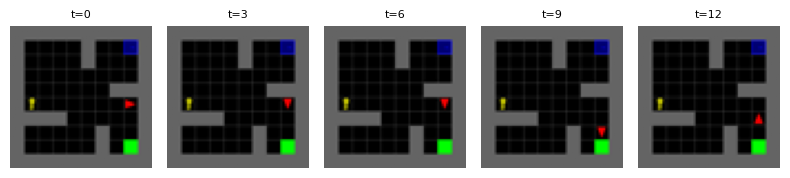

In [4]:
eps = collect_episodes(NUM_EPISODES, MAX_LEN, GRID_SIZE, seed=0)
buf = ReplayBuffer(eps)
print(len(buf.episodes), "эпизодов в буфере")

total_reward = sum(float(e["rewards"].sum()) for e in eps)
print("суммарная награда по всем эпизодам:", total_reward,
      "(разреженная — случайная политика редко доходит до цели)")

# заглянем в несколько кадров одного чанка (буфер на CPU — для imshow ок)
im, _, _ = buf.sample(1, CHUNK)
fig, ax = plt.subplots(1, 5, figsize=(8, 1.8))
for i, a in enumerate(ax):
    a.imshow((im[i * 3, 0].permute(1, 2, 0) + 0.5).clamp(0, 1))
    a.set_title(f"t={i*3}", fontsize=8); a.axis("off")
plt.tight_layout(); plt.show()

#### Запись эпизодов в папку

In [6]:
import os
from PIL import Image

def dump_episodes(eps, out_dir="episodes", max_eps=20, scale=4, fps=6, strip=True):
    """Сохранить эпизоды: GIF (движение) + полоска всех кадров (PNG).
    В имени файла: goal = агент дошёл до цели, rand = нет; и длина эпизода."""
    os.makedirs(out_dir, exist_ok=True)
    idx = (range(len(eps)) if (max_eps is None or max_eps >= len(eps))
           else np.linspace(0, len(eps) - 1, max_eps).astype(int))  # равномерный срез: и goal, и rand
    sz = 64 * scale
    for i in idx:
        imgs = eps[i]["images"]
        tag = "goal" if eps[i]["rewards"].sum() > 0 else "rand"
        frames = [Image.fromarray(f).resize((sz, sz), Image.NEAREST) for f in imgs]
        name = f"{out_dir}/ep{i:03d}_{tag}_len{len(imgs)}"
        frames[0].save(name + ".gif", save_all=True, append_images=frames[1:],
                       duration=int(1000 / fps), loop=0)
        if strip:
            s = 64
            sheet = Image.new("RGB", (s * len(imgs) + 2 * (len(imgs) - 1), s), (30, 30, 30))
            for j, f in enumerate(imgs):
                sheet.paste(Image.fromarray(f).resize((s, s), Image.NEAREST), (j * (s + 2), 0))
            sheet.save(name + "_strip.png")
    print(f"сохранено в ./{out_dir}/  (goal = дошёл до цели, rand = нет)")

#dump_episodes(eps, out_dir="episodes", max_eps=20)

## 4. Модель, оптимизатор

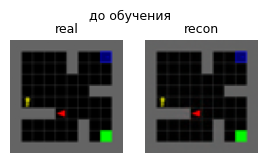

In [15]:
model = RSSM(action_dim=ACTION_DIM).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR)

#DIR = "/kaggle/working/checkpoint.pt"
#model.load_state_dict(torch.load(DIR, map_location=DEVICE))
DIR = "/kaggle/input/models/kirillwerd/world-model/pytorch/default/3/world-model.pt"
model.load_state_dict(torch.load(DIR, map_location=DEVICE))

def to_np(t):
    """(3,64,64) float [-0.5,0.5] -> (64,64,3) для imshow."""
    return (t.detach() + 0.5).clamp(0, 1).permute(1, 2, 0).cpu().numpy()


def show_recon(title=""):
    model.eval()
    with torch.no_grad():
        im, ac, rw = buf.sample(1, CHUNK)
        im, ac = im.to(DEVICE), ac.to(DEVICE)
        out = model(im, ac)
    fig, ax = plt.subplots(1, 2, figsize=(3.2, 1.8))
    ax[0].imshow(to_np(im[-1, 0])); ax[0].set_title("real", fontsize=9); ax[0].axis("off")
    ax[1].imshow(to_np(out["recon"][-1, 0])); ax[1].set_title("recon", fontsize=9); ax[1].axis("off")
    if title:
        fig.suptitle(title, fontsize=9)
    plt.show()
    model.train()


show_recon("до обучения")

### 5. Обучение

step    0 | total      6.3 | recon      0.8 | reward 0.0004 | kl 5.47
floor(post)=0.0044 | H=1:0.0042 H=3:0.0042 H=5:0.0043 H=10:0.0044
step   50 | total      4.5 | recon      0.5 | reward 0.0001 | kl 3.86
floor(post)=0.0000 | H=1:0.0000 H=3:0.0000 H=5:0.0001 H=10:0.0003
step  100 | total      4.7 | recon      0.4 | reward 0.0001 | kl 4.18
floor(post)=0.0000 | H=1:0.0000 H=3:0.0000 H=5:0.0000 H=10:0.0002
step  150 | total      4.6 | recon      0.5 | reward 0.0000 | kl 4.04
floor(post)=0.0000 | H=1:0.0000 H=3:0.0000 H=5:0.0001 H=10:0.0001


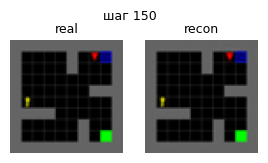

KeyboardInterrupt: 

In [16]:
os.makedirs(CKPT_DIR, exist_ok=True)

@torch.no_grad()
def openloop_report(model, buf, device, batch=BATCH, chunk=CHUNK, context=5):
    im, ac, _ = buf.sample(batch, chunk)
    im, ac = im.to(device), ac.to(device)
    h, s = model.initial(batch, device)
    prev_a = torch.zeros(batch, model.action_dim, device=device)
    for t in range(context):                              # контекст: постериор
        h, s = model.observe_step(h, s, prev_a, im[t]); prev_a = ac[t]
    floor = ((model.decoder(torch.cat([h, s], -1)) - im[context-1])**2).mean().item()
    mses = {}
    for k in range(context, chunk):                       # дальше — только прайор
        h, s = model.imagine_step(h, s, prev_a)
        mses[k-context+1] = ((model.decoder(torch.cat([h,s],-1)) - im[k])**2).mean().item()
        prev_a = ac[k]
    print(f"floor(post)={floor:.4f} | " +
          " ".join(f"H={z}:{mses[z]:.4f}" for z in (1,3,5,10) if z in mses))

for step in range(STEPS + 1):
    im, ac, rw = buf.sample(BATCH, CHUNK)
    im, ac, rw = im.to(DEVICE), ac.to(DEVICE), rw.to(DEVICE)

    loss, parts = model.loss(im, ac, rw)
    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 100)
    opt.step()

    if step % 50 == 0:
        print(f"step {step:4d} | total {loss.item():8.1f} | "
              f"recon {parts['recon']:8.1f} | reward {parts['reward']:.4f} | kl {parts['kl']:.2f}")
        openloop_report(model, buf, DEVICE, batch=BATCH, chunk=CHUNK, context=5)
    if step % 150 == 0 and step > 0:
        show_recon(f"шаг {step}")
    if step % CKPT_EVERY == 0 and step > 0:
        torch.save(model.state_dict(), "checkpoint.pt")
        print(f"Checkpoint Done")




### 6. Сохранить модель

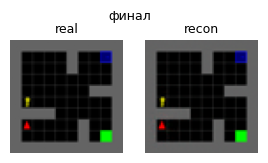

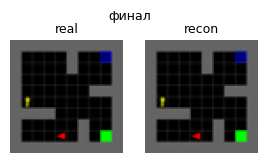

In [17]:
#final = f"{CKPT_DIR}/model.pt"
#torch.save(model.state_dict(), final)
#print("финальная модель ->", final)

show_recon("финал")

DIR = "/kaggle/input/models/kirillwerd/world-model/pytorch/default/3/world-model.pt"
model.load_state_dict(torch.load(DIR, map_location=DEVICE))
show_recon("финал")

### 7. Первый тест: умеет ли модель «воображать» будущее?

Прогреваем состояние на нескольких **реальных** кадрах через `observe_step`
(posterior), дальше катим вперёд **без кадров** через `imagine_step` (prior) и
декодируем каждый шаг. Сверху — реальные кадры, снизу — что модель «досняла»
вслепую. Статичная сцена (стены, дверь, ключ, цель) должна проступать.

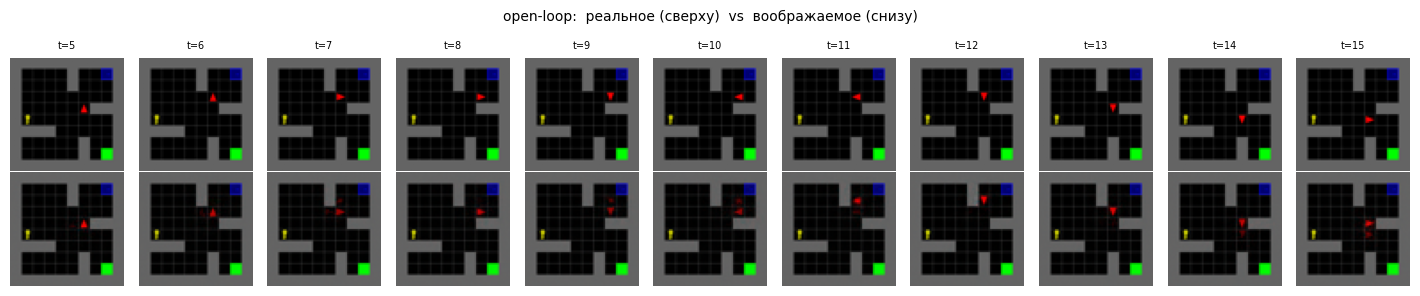

In [22]:
model.eval()
WARMUP = 5
with torch.no_grad():
    im, ac, rw = buf.sample(1, CHUNK)
    im, ac = im.to(DEVICE), ac.to(DEVICE)
    T = im.shape[0]
    h, s = model.initial(1, DEVICE)
    prev_a = torch.zeros(1, ACTION_DIM, device=DEVICE)

    for t in range(WARMUP):                       # фильтрация по реальным кадрам
        h, s = model.observe_step(h, s, prev_a, im[t])
        prev_a = ac[t]

    imagined = []
    for t in range(WARMUP, T):                    # воображение без кадров
        h, s = model.imagine_step(h, s, prev_a)
        imagined.append(model.decoder(torch.cat([h, s], dim=-1))[0])
        prev_a = ac[t]

n = T - WARMUP-4
fig, ax = plt.subplots(2, n, figsize=(1.3 * n, 3))
for i in range(n):
    ax[0, i].imshow(to_np(im[WARMUP + i, 0])); ax[0, i].axis("off")
    ax[1, i].imshow(to_np(imagined[i]));        ax[1, i].axis("off")
    ax[0, i].set_title(f"t={WARMUP+i}", fontsize=7)
fig.suptitle("open-loop:  реальное (сверху)  vs  воображаемое (снизу)", fontsize=10)
plt.tight_layout(); plt.show()